# IEA-22 spanwise: RM shell homogenization + stress/disp recovery vs VABS (51 stations)

This tutorial runs the **Reissner–Mindlin (RM) shell** cross-sectional model along the
full span of the **IEA-22 MW** reference blade — **51 stations** — and compares it to
**VABS** in two ways:

1. **Homogenization** — the RM Timoshenko `6×6` diagonal vs the VABS `.sg.K`, as a
   spanwise `%`-error with the `±5%` band, one panel per stiffness term.
2. **Dehomogenization (recovery)** — the pointwise **3-D stress** and the **total
   displacement** at one near-root-band *suction-crown* landmark per station, driven by
   the BeamDyn section loads, vs the VABS `.sg.SM` / `.sg.U` values at the same point.

Everything is homogenized at the **CENTER (mid-surface) reference** — the same reference
the BeamDyn `6×6` and section forces use, so the recovery stays self-consistent.

It runs **entirely from data committed to this repository** — clone and execute top to
bottom; nothing is read from a local machine.  The full per-station VABS `.SM`/`.U` dumps
(~875 MB) are **not** committed; only the small per-station *landmark* they define is,
pre-extracted into a 21 KB `.npz` (see `benchmark/_extract_landmarks.py`).

**Inputs (all under `examples/data/iea_all_stations/`):**

| file | role |
|------|------|
| `shell51/1d_yaml/iea_s00..s50_shell.yaml` | 51 center-ref 1-D shell structure-genes (RM homogenization input) |
| `dehom51/beamdyn/ff51_rmc_reform.dat` | per-station beam section forces `FF` (VABS order `F1 F2 F3 M1 M2 M3`) |
| `dehom51/beamdyn/iea51rmc_bd_driver.out` | BeamDyn nodal translation/rotation (removes beam kinematics in the disp recovery) |
| `dehom51/benchmark/spanwise_vabs_landmarks.npz` | pre-extracted VABS landmark per station: point `(y2,y3)`, stress 6-vec, disp 3-vec, Timoshenko `6×6` |

In [1]:
import os, sys
import numpy as np
os.environ["CUDA_VISIBLE_DEVICES"] = ""

def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and \
           os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        p = os.path.dirname(d)
        if p == d:
            raise RuntimeError("run this from inside the OpenSG-TW repo")
        d = p

CC = _find_repo_root()
XSEC = os.path.join(CC, "examples", "TW-paper", "xsec_paper")
MITC = os.path.join(CC, "mitc_rm_segment")
for q in (CC, XSEC, MITC):
    if q not in sys.path:
        sys.path.insert(0, q)
import jax; jax.config.update("jax_enable_x64", True)
import dehom_rm     # RM-consistent thin-walled homogenization + two-step dehom

DATA   = os.path.join(CC, "examples", "data", "iea_all_stations")
SHELLD = os.path.join(DATA, "shell51", "1d_yaml")                    # center / mid-surface set
BEAM   = os.path.join(DATA, "dehom51", "beamdyn")
BENCH  = os.path.join(DATA, "dehom51", "benchmark", "spanwise_vabs_landmarks.npz")
FF_ALL = np.loadtxt(os.path.join(BEAM, "ff51_rmc_reform.dat"))       # 51 x [eta, F1..F3, M1..M3]
BD_OUT = os.path.join(BEAM, "iea51rmc_bd_driver.out")
print("repo root:", CC)

repo root: /home/roger/a/bagla0/OpenSG-TW-claude


## 1. Homogenize + recover along the span

For each of the 51 stations we

* **homogenize** the RM shell ring from its 1-D yaml (`dehom_rm.build_rm_bundle`, center
  reference read from the yaml's `reference:` field) → RM Timoshenko `6×6`, and take the
  diagonal `%`-error against the VABS `.sg.K` stored in the npz;
* **recover** the 3-D stress at the landmark with the two-step MSG dehom
  (`stress_at_points`: `FF → shell strains → 3-D stress`), and the RM warping
  displacement (`disp_at_points`), then lift it to the global frame by adding the BeamDyn
  beam kinematics `u = u_g + C·(w + r) − r` so it is comparable to the VABS `.sg.U`.

`beam_kin` pulls the last-time BeamDyn translation `TD` and rotation `RD` at the station
node and builds the small-rotation matrix `C`.  The stress reindex `SVOIGT` maps the RM
Voigt order `[11,22,33,23,13,12]` to `[11,12,13,22,23,33]` so it lines up with the VABS
`.SM` landmark columns.

In [2]:
BE = ("11", "12", "13", "22", "23", "33")
SVOIGT = {"11": 0, "12": 5, "13": 4, "22": 1, "23": 3, "33": 2}

def beam_kin(path, node):
    L = [l for l in open(path).read().splitlines() if l.strip()]
    for i, l in enumerate(L):
        if l.strip().startswith("Time"):
            h = l.split(); row = np.array([rr.split() for rr in L[i + 2:]], float)[-1]
            g = lambda nm: row[h.index("N%03d_%s" % (node, nm))]
            TD = np.array([g("TDxr"), g("TDyr"), g("TDzr")]); RD = np.array([g("RDxr"), g("RDyr"), g("RDzr")])
            u_g = np.array([TD[2], -TD[1], TD[0]]); t1, t2, t3 = RD[2], -RD[1], RD[0]
            return u_g, np.array([[1.0, -t3, t2], [t3, 1.0, -t1], [-t2, t1, 1.0]])
    raise ValueError("no BeamDyn Time header")

Z = np.load(BENCH)
LM_idx, LM_pt, LM_VS, LM_VU, LM_K = Z["idx"], Z["pt"], Z["VS"], Z["VU"], Z["K"]

eta, diag, S, U, VS, VU = [], [], [], [], [], []
for j, ii in enumerate(LM_idx):
    i = int(ii)
    shp = os.path.join(SHELLD, "iea_s%02d_shell.yaml" % i)
    if not os.path.exists(shp):
        continue
    try:
        pt, Kv, Vs, Vu = LM_pt[j], LM_K[j], LM_VS[j], LM_VU[j]
        FF = FF_ALL[i, 1:]
        B = dehom_rm.build_rm_bundle(shp); C6 = np.asarray(B["Timo"])
        de = 100.0 * (np.diag(C6) - np.diag(Kv)) / np.diag(Kv)
        s = np.asarray(dehom_rm.stress_at_points(B, pt[None], beam_force_vabs=FF,
                       frame="material", n_per_layer=4, flow_avg=True)["stress"])[0]
        w = np.asarray(dehom_rm.disp_at_points(B, pt[None], beam_force_vabs=FF))[0]
        u_g, C = beam_kin(BD_OUT, i + 1); r3 = np.array([0.0, pt[0], pt[1]])
        eta.append(i / 50.0); diag.append(de); S.append([s[SVOIGT[k]] for k in BE])
        U.append(u_g + C @ (w + r3) - r3); VS.append(Vs.tolist()); VU.append(Vu.tolist())
        print("s%02d ok  GA3 %+6.2f%%  u3 RM %.3f / VABS %.3f" % (i, de[2], U[-1][2], Vu[2]), flush=True)
    except Exception as e:
        print("s%02d FAIL %s" % (i, str(e)[:70]), flush=True)

eta = np.array(eta); diag = np.array(diag); S = np.array(S); U = np.array(U)
VS = np.array(VS); VU = np.array(VU)
LBLK = ["EA", "GA2", "GA3", "GJ", "EI2", "EI3"]
print("\n%d/%d stations reproduced" % (len(eta), len(LM_idx)))
print("mean |%err| RM 6x6 vs VABS .K:  " +
      "  ".join("%s %.2f" % (LBLK[k], np.nanmean(np.abs(diag[:, k]))) for k in range(6)))

s00 ok  GA3  -0.04%  u3 RM 0.001 / VABS 0.001


s01 ok  GA3  -0.06%  u3 RM 0.003 / VABS 0.003


s02 ok  GA3 +13.24%  u3 RM 0.008 / VABS 0.008


s03 ok  GA3  +0.68%  u3 RM 0.019 / VABS 0.019


s04 ok  GA3  +0.29%  u3 RM 0.036 / VABS 0.036


...

s47 ok  GA3  -1.63%  u3 RM 15.341 / VABS 15.336


s48 ok  GA3  -1.74%  u3 RM 16.117 / VABS 16.113


s49 ok  GA3  -1.55%  u3 RM 16.897 / VABS 16.896


s50 ok  GA3 -13.41%  u3 RM 17.673 / VABS 17.677



51/51 stations reproduced
mean |%err| RM 6x6 vs VABS .K:  EA 0.85  GA2 1.93  GA3 1.57  GJ 1.57  EI2 0.23  EI3 2.54


## 2. Homogenization accuracy across the span

RM Timoshenko `6×6` diagonal vs VABS `.sg.K`, per term, as a `%`-error along `r/R` with
the `±5%` band shaded.  The extension `EA`, torsion `GJ`, and both bending terms
`EI_2, EI_3` sit inside the band over essentially the whole blade; the transverse-shear
terms `GA_2, GA_3` are the hardest for a shell and drift most near the thick inboard
root, where the wall becomes non-thin.

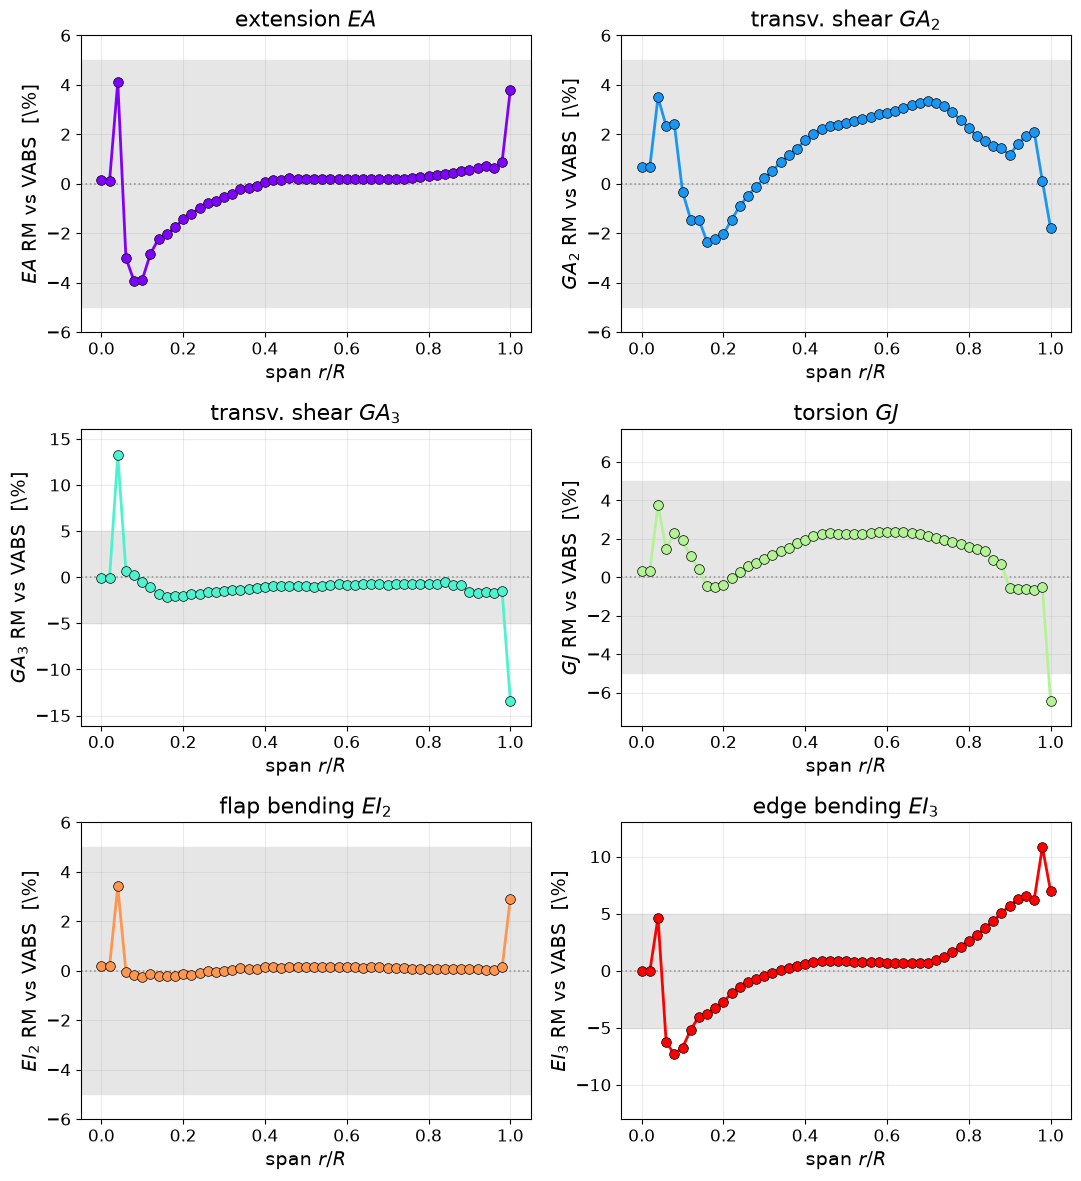

In [3]:
import matplotlib.pyplot as plt
LBL = ["EA", "GA_2", "GA_3", "GJ", "EI_2", "EI_3"]
TIT = ["extension $EA$", "transv. shear $GA_2$", "transv. shear $GA_3$",
       "torsion $GJ$", "flap bending $EI_2$", "edge bending $EI_3$"]
col = plt.cm.rainbow(np.linspace(0, 1, 6))
plt.rcParams.update({"font.size": 13, "axes.labelsize": 14, "xtick.labelsize": 12,
                     "ytick.labelsize": 12, "legend.fontsize": 12})
fig, axs = plt.subplots(3, 2, figsize=(11, 12))
for k in range(6):
    ax = axs.flat[k]
    ax.axhspan(-5, 5, color="0.9", zorder=0); ax.axhline(0, color="0.6", lw=1.2, ls=":")
    ax.plot(eta, diag[:, k], "-o", color=col[k], mec="k", mew=0.5, ms=7, lw=2.0)
    mx = np.nanmax(np.abs(diag[:, k])); ax.set_ylim(-max(6, 1.2 * mx), max(6, 1.2 * mx))
    ax.set_xlabel(r"span $r/R$"); ax.set_ylabel(r"$%s$ RM vs VABS  [\%%]" % LBL[k])
    ax.set_title(TIT[k]); ax.grid(alpha=0.25)
fig.tight_layout(); plt.show()

## 3. Spanwise stress recovery at the suction-crown landmark

3-D stress recovered by the RM two-step dehom vs VABS `.sg.SM`, at the near-root-band
max-`y3` point of each section.  `σ11` (axial) is set by the flap moment and tracks VABS
across the span; the in-plane shear/transverse `σ12, σ22` are ~two orders smaller and also
follow VABS.  A robust `8×median` outlier mask on `σ11` drops the handful of stations whose
landmark lands on a web/skin junction where the 1-D shell reference folds.

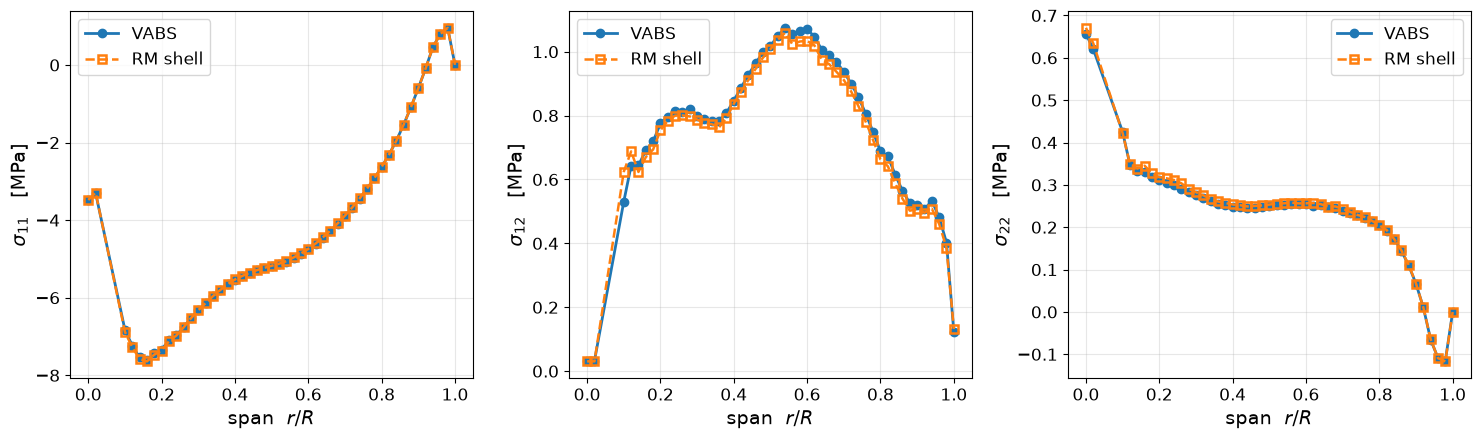

In [4]:
VABSC = "#1f77b4"; RMC = "#ff7f0e"
SIN = [("11", 0), ("12", 1), ("22", 3)]; SLAB = [r"$\sigma_{11}$", r"$\sigma_{12}$", r"$\sigma_{22}$"]
d0 = np.abs(S[:, 0] - VS[:, 0]); keep = d0 <= 8.0 * np.median(d0) + 1e-12
fig, axs = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (k, idx), lab in zip(axs, SIN, SLAB):
    ax.plot(eta[keep], VS[keep, idx] / 1e6, "-o", color=VABSC, ms=6, lw=2.0, label="VABS")
    ax.plot(eta[keep], S[keep, idx] / 1e6, "--s", color=RMC, ms=6, mfc="none", mew=1.8,
            lw=1.8, label="RM shell")
    ax.set_xlabel(r"span  $r/R$"); ax.set_ylabel("%s   [MPa]" % lab); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()

## 4. Spanwise displacement recovery

Total displacement at the landmark — RM warping lifted to the global frame by the BeamDyn
beam kinematics — vs VABS `.sg.U`.  The flapwise `u_3` is the blade tip-deflection build-up
(0 at the root to ~18 m near the tip) and the RM recovery lies on top of VABS along the
whole span; the small edgewise `u_2` and out-of-plane warping `u_1` also match.

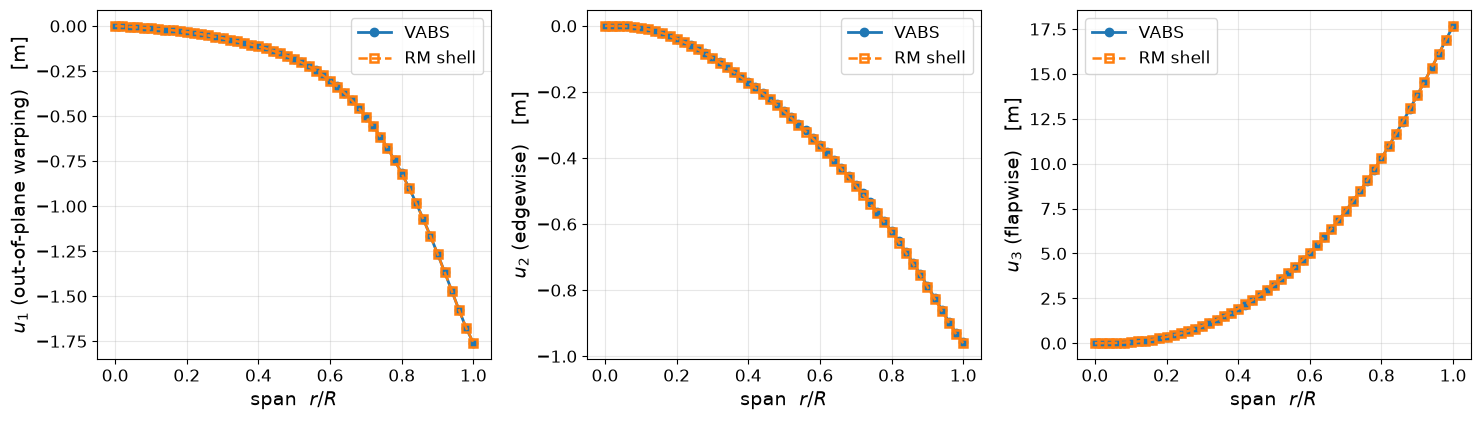

In [5]:
ULAB = [r"$u_1$ (out-of-plane warping)", r"$u_2$ (edgewise)", r"$u_3$ (flapwise)"]
fig, axs = plt.subplots(1, 3, figsize=(15, 4.4))
for k, (ax, lab) in enumerate(zip(axs, ULAB)):
    ax.plot(eta, VU[:, k], "-o", color=VABSC, ms=6, lw=2.0, label="VABS")
    ax.plot(eta, U[:, k], "--s", color=RMC, ms=6, mfc="none", mew=1.8, lw=1.8, label="RM shell")
    ax.set_xlabel(r"span  $r/R$"); ax.set_ylabel("%s   [m]" % lab); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); plt.show()

## What this shows

* A **single RM shell cross-sectional model**, run station-by-station, reproduces the VABS
  Timoshenko `6×6` within a few percent over the whole IEA-22 blade for the extension,
  bending, and torsion stiffnesses; the transverse-shear terms are the shell model's limit
  and degrade first at the thick inboard root (see `ref_rm_regime_guard`).
* The **same** model dehomogenizes: driven by the BeamDyn section loads it recovers the
  pointwise 3-D stress and the total displacement at a chosen section point, matching VABS
  to plotting accuracy across the span — at a fraction of the cost of a per-station 2-D
  solid VABS analysis.

## Further reading (in this repo)

* `examples/TW-paper/xsec_paper/dehom_rm.py` — the RM-consistent two-step dehom used here.
* `docs/tutorials/st15_dehomogenization.ipynb` — the single-station through-thickness /
  circumferential stress recovery, with the MSG plate-SG derivation.
* `examples/data/iea_all_stations/dehom51/benchmark/_extract_landmarks.py` — the one-off
  pre-extraction that packs the per-station VABS landmark into the committed `.npz`.